<table width="100%">
<tr>
<td width="50%" align="left"><a href="./00_EDA.ipynb">← Previous: EDA</a></td>
<td width="50%" align="right"><a href="./02_RQ2_capacity_workforce.ipynb">Next: RQ2 — Capacity Workforce →</a></td>
</tr>
</table>

## **1.0 Population Size and Demographic Composition Changes**

#### This section looks at how Population size and demographic composition of Canadian provinces have evolved as well as the implication of this changes on healthcare demand

> - #### **Research Quesiton 1: How have population size and demographic composition changed across Canadian provinces and what implications do these changes have for healthcare demand?**

In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
from database_db_core.connection import get_db_engine

In [3]:
DATABASE = "health_system_performance"

engine = get_db_engine(DATABASE)

print("Connected database:", engine.url.database)

Connected database: health_system_performance


In [4]:
query = """
SELECT *
FROM master.analytics_province_year;
"""

df = pd.read_sql(query, engine)

print("Connected successfully to database!")

df.head(10)

Connected successfully to database!


,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,private_health_expenditure_constant_2010_per_capita,provincial_government_health_expenditure_current,provincial_government_health_expenditure_per_capita,provincial_government_health_expenditure_constant_2010,provincial_government_health_expenditure_constant_2010_per_capi,territorial_government_health_expenditure_current,territorial_government_health_expenditure_per_capita,territorial_government_health_expenditure_constant_2010,territorial_government_health_expenditure_constant_2010_per_cap,nurses_total
0,15,PE,Prince Edward Island,2024,179709.0,36849.0,8218.0,3886.0,20.504816,4.572948,...,1914.110532,1.228779e+09,6881.989110,8.254174e+08,4622.892113,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,663.549287,6.949125e+08,384.207843,3.428803e+09,1895.739423,NaN,NaN,NaN,NaN,NaN
2,7,BC,British Columbia,1975,2499564.0,236960.0,51071.0,23239.0,9.480053,2.043196,...,679.794364,9.281825e+08,371.337761,4.379023e+09,1751.914626,NaN,NaN,NaN,NaN,NaN
3,7,BC,British Columbia,2022,5358845.0,1054174.0,250939.0,124925.0,19.671664,4.682707,...,2273.051979,3.010337e+10,5618.936230,2.317900e+10,4326.469070,NaN,NaN,NaN,NaN,108708.0
4,9,NB,New Brunswick,2021,790802.0,178652.0,39837.0,19193.0,22.591243,5.037544,...,2191.698134,3.945472e+09,4989.203072,3.151362e+09,3985.020465,NaN,NaN,NaN,NaN,NaN
5,5,CA,Canada,1975,23143275.0,1957075.0,377982.0,160362.0,8.456344,1.633226,...,568.363206,8.709289e+09,376.320519,4.111742e+10,1776.646681,NaN,NaN,NaN,NaN,NaN
6,8,MB,Manitoba,1975,1024975.0,104215.0,22287.0,9920.0,10.167565,2.174394,...,494.535967,3.766992e+08,367.520427,1.852127e+09,1806.997401,NaN,NaN,NaN,NaN,NaN
7,14,ON,Ontario,1980,8746013.0,850356.0,165961.0,70416.0,9.722785,1.897562,...,776.538159,5.164564e+09,590.505011,1.629120e+10,1862.700006,NaN,NaN,NaN,NaN,NaN
8,16,QC,Quebec,2020,8551095.0,1673371.0,401828.0,204785.0,19.569084,4.699141,...,1755.558556,4.704125e+10,5501.196296,3.642464e+10,4259.646558,NaN,NaN,NaN,NaN,NaN
9,14,ON,Ontario,2016,13876500.0,2260652.0,593482.0,302656.0,16.291226,4.276885,...,2000.807682,5.655294e+10,4075.446981,5.104966e+10,3678.856840,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 81 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   province_id                                                      730 non-null    int64  
 1   province_code                                                    730 non-null    str    
 2   province_name                                                    730 non-null    str    
 3   data_year                                                        730 non-null    int64  
 4   population                                                       730 non-null    float64
 5   population_65_plus                                               730 non-null    float64
 6   population_80_plus                                               730 non-null    float64
 7   population_85_plus                                     

In [6]:
df.columns.tolist()

['province_id',
 'province_code',
 'province_name',
 'data_year',
 'population',
 'population_65_plus',
 'population_80_plus',
 'population_85_plus',
 'population_65_share_pct',
 'population_80_share_pct',
 'population_85_share_pct',
 'hospital_beds_total',
 'current_hospital_beds_total',
 'physicians_total',
 'registered_nurses',
 'licensed_practical_nurses',
 'nurse_practitioners',
 'registered_psychiatric_nurses',
 'icu_beds',
 'long_term_care_beds',
 'mental_health_addictions_beds',
 'obstetrics_beds',
 'other_acute_care_beds',
 'pediatrics_beds',
 'rated_capacity_beds',
 'rehabilitation_beds',
 'bladder_cancer_surgery_median',
 'bladder_cancer_surgery_90th_percentile',
 'breast_cancer_surgery_median',
 'breast_cancer_surgery_90th_percentile',
 'cabg_median',
 'cabg_90th_percentile',
 'cataract_surgery_median',
 'cataract_surgery_90th_percentile',
 'colorectal_cancer_surgery_median',
 'colorectal_cancer_surgery_90th_percentile',
 'ct_scan_median',
 'ct_scan_90th_percentile',
 'hip_

In [7]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

01. province_id
02. province_code
03. province_name
04. data_year
05. population
06. population_65_plus
07. population_80_plus
08. population_85_plus
09. population_65_share_pct
10. population_80_share_pct
11. population_85_share_pct
12. hospital_beds_total
13. current_hospital_beds_total
14. physicians_total
15. registered_nurses
16. licensed_practical_nurses
17. nurse_practitioners
18. registered_psychiatric_nurses
19. icu_beds
20. long_term_care_beds
21. mental_health_addictions_beds
22. obstetrics_beds
23. other_acute_care_beds
24. pediatrics_beds
25. rated_capacity_beds
26. rehabilitation_beds
27. bladder_cancer_surgery_median
28. bladder_cancer_surgery_90th_percentile
29. breast_cancer_surgery_median
30. breast_cancer_surgery_90th_percentile
31. cabg_median
32. cabg_90th_percentile
33. cataract_surgery_median
34. cataract_surgery_90th_percentile
35. colorectal_cancer_surgery_median
36. colorectal_cancer_surgery_90th_percentile
37. ct_scan_median
38. ct_scan_90th_percentile
39. hi

In [8]:
df.isna().sum()

province_id                                                          0
province_code                                                        0
province_name                                                        0
data_year                                                            0
population                                                           0
                                                                  ... 
territorial_government_health_expenditure_current                  617
territorial_government_health_expenditure_per_capita               617
territorial_government_health_expenditure_constant_2010            617
territorial_government_health_expenditure_constant_2010_per_cap    617
nurses_total                                                       697
Length: 81, dtype: int64

In [9]:
query = """
    SELECT
    province_id,
    province_code,
    province_name,
    data_year,
    population,
    population_65_plus,
    population_80_plus,
    population_85_plus,
    population_65_share_pct,
    population_80_share_pct,
    population_85_share_pct
FROM master.analytics_province_year
WHERE province_code NOT IN ('NT', 'YT', 'NU')
ORDER BY province_name, data_year;
"""

df_population_demand = pd.read_sql(query, engine)

df_population_demand.head()

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055


### **1.1 Population Growth**

In [10]:
df_population_demand["population_growth_pct"] = (
    df_population_demand
    .groupby('province_code')["population"]
    .pct_change() * 100
)

df_population_demand

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct,population_growth_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059,1.703351
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135,1.843881
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370,1.697881
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055,3.081463
...,...,...,...,...,...,...,...,...,...,...,...,...
600,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,2.346385,0.027840
601,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,2.287928,0.949293
602,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,2.228618,2.668910
603,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,2.164812,3.107687


In [11]:
df_population_demand["population_65_plus_growth_pct"] = (
df_population_demand
.groupby("province_code")["population_65_plus"]
.pct_change() * 100
)

In [12]:
df_population_demand["population_80_plus_growth_pct"] = (
df_population_demand
.groupby("province_code")["population_80_plus"]
.pct_change() * 100
)

In [13]:
df_population_demand["population_85_plus_growth_pct"] = (
df_population_demand
.groupby("province_code")["population_85_plus"]
.pct_change() * 100
)


In [14]:
df_population_demand[
    [
        "province_name",
        "province_code",
        "population",
        "population_growth_pct"
    ]
    
].head()

,province_name,province_code,population,population_growth_pct
0,Alberta,AB,1665717.0,NaN
1,Alberta,AB,1694090.0,1.703351
2,Alberta,AB,1725327.0,1.843881
3,Alberta,AB,1754621.0,1.697881
4,Alberta,AB,1808689.0,3.081463


In [15]:
df_population_demand["population_growth_pct"].describe()

count    594.000000
mean       0.960535
std        0.925226
min       -2.009036
25%        0.378597
50%        0.935154
75%        1.358357
max        4.701939
Name: population_growth_pct, dtype: float64

### **1.2 Population Change over the period 1971-2025**

In [16]:
df_population_change = (
    df_population_demand
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "min"),
        end_year=("data_year", "max"),
        start_population=("population", "first"),
        end_population=("population", "last")
        
    )
    .reset_index()
)

df_population_change

,province_code,province_name,start_year,end_year,start_population,end_population
0,AB,Alberta,1971,2025,1665717.0,5029346.0
1,BC,British Columbia,1971,2025,2240470.0,5697536.0
2,CA,Canada,1971,2025,21962032.0,41651653.0
3,MB,Manitoba,1971,2025,998876.0,1509702.0
4,NB,New Brunswick,1971,2025,642471.0,869682.0
5,NL,Newfoundland and Labrador,1971,2025,530854.0,549911.0
6,NS,Nova Scotia,1971,2025,797294.0,1093245.0
7,ON,Ontario,1971,2025,7849027.0,16258260.0
8,PE,Prince Edward Island,1971,2025,112591.0,182657.0
9,QC,Quebec,1971,2025,6137305.0,9058297.0


In [17]:
df_population_change["absolute_change"] =(
    df_population_change["end_population"] - 
    df_population_change["start_population"]
)

In [18]:
df_population_change["population_change_pct"] = (
    df_population_change["absolute_change"]
    / df_population_change["start_population"]
) * 100

In [19]:

df_population_change

,province_code,province_name,start_year,end_year,start_population,end_population,absolute_change,population_change_pct
0,AB,Alberta,1971,2025,1665717.0,5029346.0,3363629.0,201.932801
1,BC,British Columbia,1971,2025,2240470.0,5697536.0,3457066.0,154.300928
2,CA,Canada,1971,2025,21962032.0,41651653.0,19689621.0,89.653002
3,MB,Manitoba,1971,2025,998876.0,1509702.0,510826.0,51.140081
4,NB,New Brunswick,1971,2025,642471.0,869682.0,227211.0,35.365176
5,NL,Newfoundland and Labrador,1971,2025,530854.0,549911.0,19057.0,3.589876
6,NS,Nova Scotia,1971,2025,797294.0,1093245.0,295951.0,37.119431
7,ON,Ontario,1971,2025,7849027.0,16258260.0,8409233.0,107.137267
8,PE,Prince Edward Island,1971,2025,112591.0,182657.0,70066.0,62.230551
9,QC,Quebec,1971,2025,6137305.0,9058297.0,2920992.0,47.594050


### **1.3 Figures**

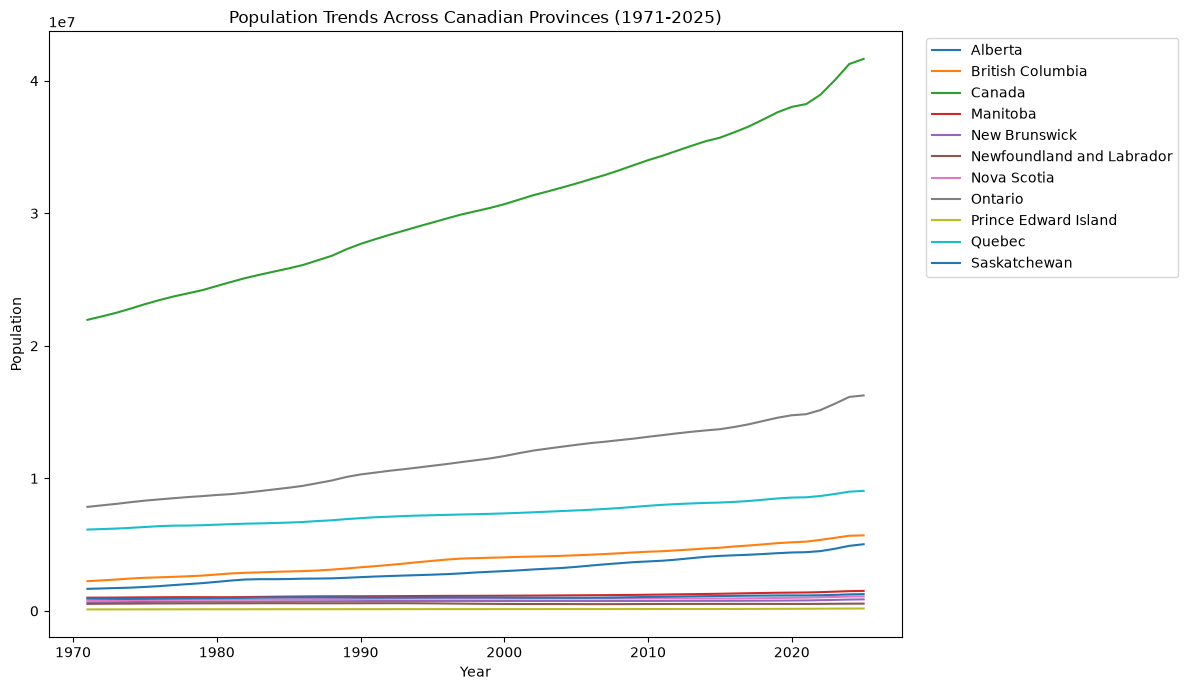

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for province, group in df_population_demand.groupby("province_name"):
    plt.plot(
        group["data_year"],
        group["population"],
        label=province
    )   

plt.title("Population Trends Across Canadian Provinces (1971-2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
df_population_change.sort_values(
    "absolute_change", ascending=False
)

,province_code,province_name,start_year,end_year,start_population,end_population,absolute_change,population_change_pct
2,CA,Canada,1971,2025,21962032.0,41651653.0,19689621.0,89.653002
7,ON,Ontario,1971,2025,7849027.0,16258260.0,8409233.0,107.137267
1,BC,British Columbia,1971,2025,2240470.0,5697536.0,3457066.0,154.300928
0,AB,Alberta,1971,2025,1665717.0,5029346.0,3363629.0,201.932801
9,QC,Quebec,1971,2025,6137305.0,9058297.0,2920992.0,47.594050
3,MB,Manitoba,1971,2025,998876.0,1509702.0,510826.0,51.140081
10,SK,Saskatchewan,1971,2025,932038.0,1266959.0,334921.0,35.934264
6,NS,Nova Scotia,1971,2025,797294.0,1093245.0,295951.0,37.119431
4,NB,New Brunswick,1971,2025,642471.0,869682.0,227211.0,35.365176
8,PE,Prince Edward Island,1971,2025,112591.0,182657.0,70066.0,62.230551


In [22]:
df_population_change.sort_values(
    "population_change_pct",
    ascending=False
)

,province_code,province_name,start_year,end_year,start_population,end_population,absolute_change,population_change_pct
0,AB,Alberta,1971,2025,1665717.0,5029346.0,3363629.0,201.932801
1,BC,British Columbia,1971,2025,2240470.0,5697536.0,3457066.0,154.300928
7,ON,Ontario,1971,2025,7849027.0,16258260.0,8409233.0,107.137267
2,CA,Canada,1971,2025,21962032.0,41651653.0,19689621.0,89.653002
8,PE,Prince Edward Island,1971,2025,112591.0,182657.0,70066.0,62.230551
3,MB,Manitoba,1971,2025,998876.0,1509702.0,510826.0,51.140081
9,QC,Quebec,1971,2025,6137305.0,9058297.0,2920992.0,47.594050
6,NS,Nova Scotia,1971,2025,797294.0,1093245.0,295951.0,37.119431
10,SK,Saskatchewan,1971,2025,932038.0,1266959.0,334921.0,35.934264
4,NB,New Brunswick,1971,2025,642471.0,869682.0,227211.0,35.365176


### **1.4 Population Ageing Demography**

In [23]:
df_population_aging = df_population_demand[
    [
        "province_code",
        "province_name",
        "data_year",
        "population_65_plus",
        "population_80_plus",
        "population_85_plus",
        "population_65_share_pct",
        "population_80_share_pct",
        "population_85_share_pct"
    ]
].copy()

In [24]:
df_population_aging

,province_code,province_name,data_year,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct
0,AB,Alberta,1971,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217
1,AB,Alberta,1972,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059
2,AB,Alberta,1973,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135
3,AB,Alberta,1974,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370
4,AB,Alberta,1975,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055
...,...,...,...,...,...,...,...,...,...
600,SK,Saskatchewan,2021,198565.0,50771.0,27399.0,17.004636,4.347908,2.346385
601,SK,Saskatchewan,2022,204647.0,50862.0,26970.0,17.360680,4.314741,2.287928
602,SK,Saskatchewan,2023,211510.0,51537.0,26972.0,17.476453,4.258352,2.228618
603,SK,Saskatchewan,2024,218531.0,52274.0,27014.0,17.512349,4.189065,2.164812


In [25]:
df_population_demand["growth_65_plus_pct"] = (
    df_population_demand
    .groupby("province_code")["population_65_plus"]
    .pct_change() * 100
)

In [26]:
df_population_demand["growth_80_plus_pct"] = (
df_population_demand
.groupby("province_code")["population_80_plus"]
.pct_change() * 100
)

In [27]:
df_population_demand["growth_85_plus_pct"] = (
df_population_demand
.groupby("province_code")["population_85_plus"]
.pct_change() * 100
)

In [28]:
df_population_demand

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct,population_growth_pct,population_65_plus_growth_pct,population_80_plus_growth_pct,population_85_plus_growth_pct,growth_65_plus_pct,growth_80_plus_pct,growth_85_plus_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059,1.703351,2.602675,2.948345,4.438692,2.602675,2.948345,4.438692
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135,1.843881,2.748649,1.836719,4.865063,2.748649,1.836719,4.865063
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370,1.697881,2.409733,1.421126,4.805672,2.409733,1.421126,4.805672
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055,3.081463,3.161213,1.456670,2.580807,3.161213,1.456670,2.580807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,2.346385,0.027840,3.354136,0.856178,-0.047424,3.354136,0.856178,-0.047424
601,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,2.287928,0.949293,3.062977,0.179236,-1.565751,3.062977,0.179236,-1.565751
602,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,2.228618,2.668910,3.353580,1.327120,0.007416,3.353580,1.327120,0.007416
603,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,2.164812,3.107687,3.319465,1.430041,0.155717,3.319465,1.430041,0.155717


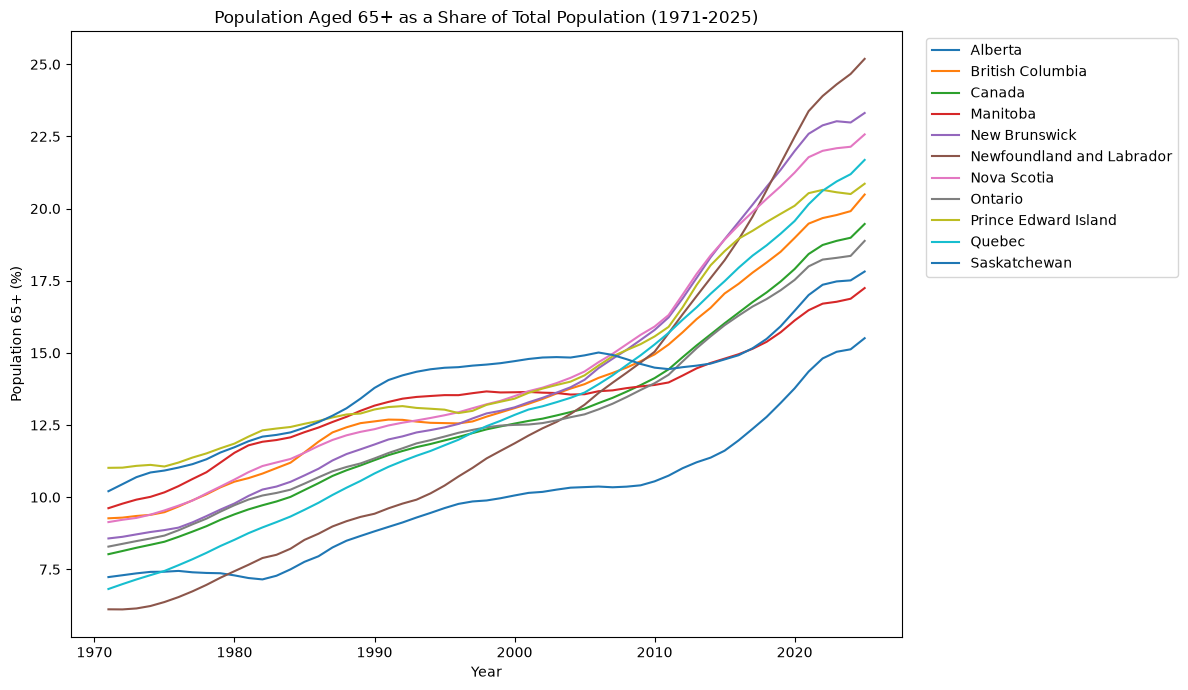

In [29]:
plt.figure(figsize=(12,7))
for province, group in df_population_demand.groupby("province_name"):
    plt.plot(
        group["data_year"],
        group["population_65_share_pct"],
        label=province
    )

plt.title("Population Aged 65+ as a Share of Total Population (1971-2025)")
plt.xlabel("Year")
plt.ylabel("Population 65+ (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

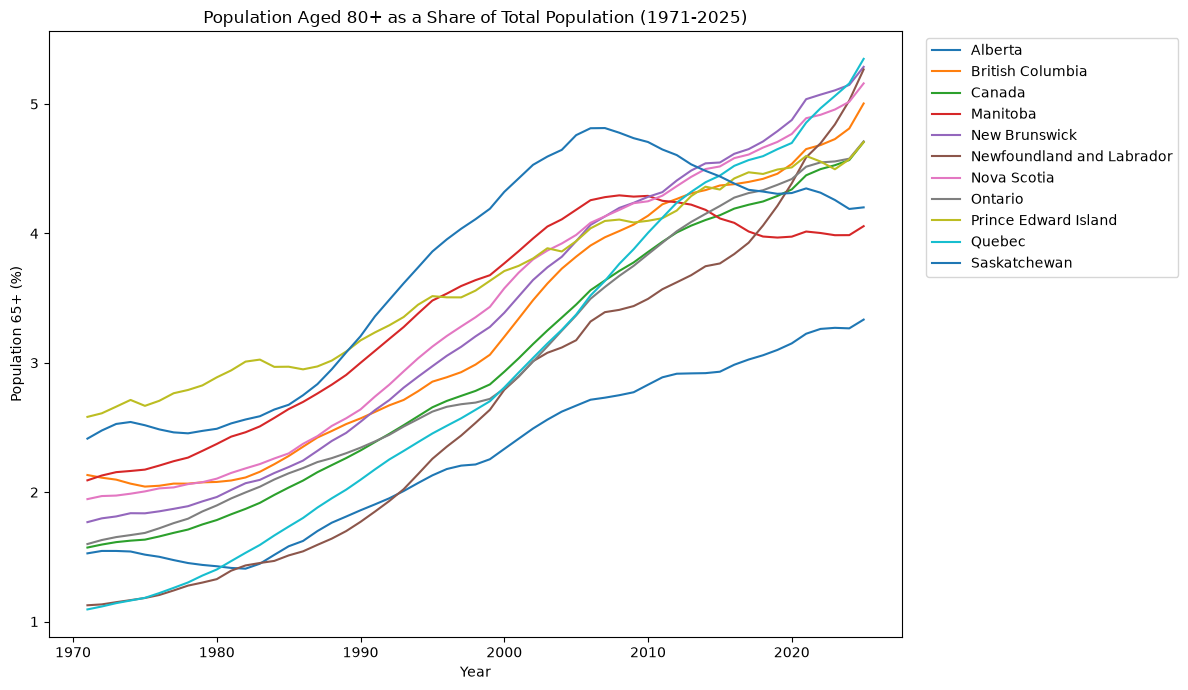

In [30]:
plt.figure(figsize=(12,7))
for province, group in df_population_demand.groupby("province_name"):
    plt.plot(
        group["data_year"],
        group["population_80_share_pct"],
        label=province
    )

plt.title("Population Aged 80+ as a Share of Total Population (1971-2025)")
plt.xlabel("Year")
plt.ylabel("Population 65+ (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

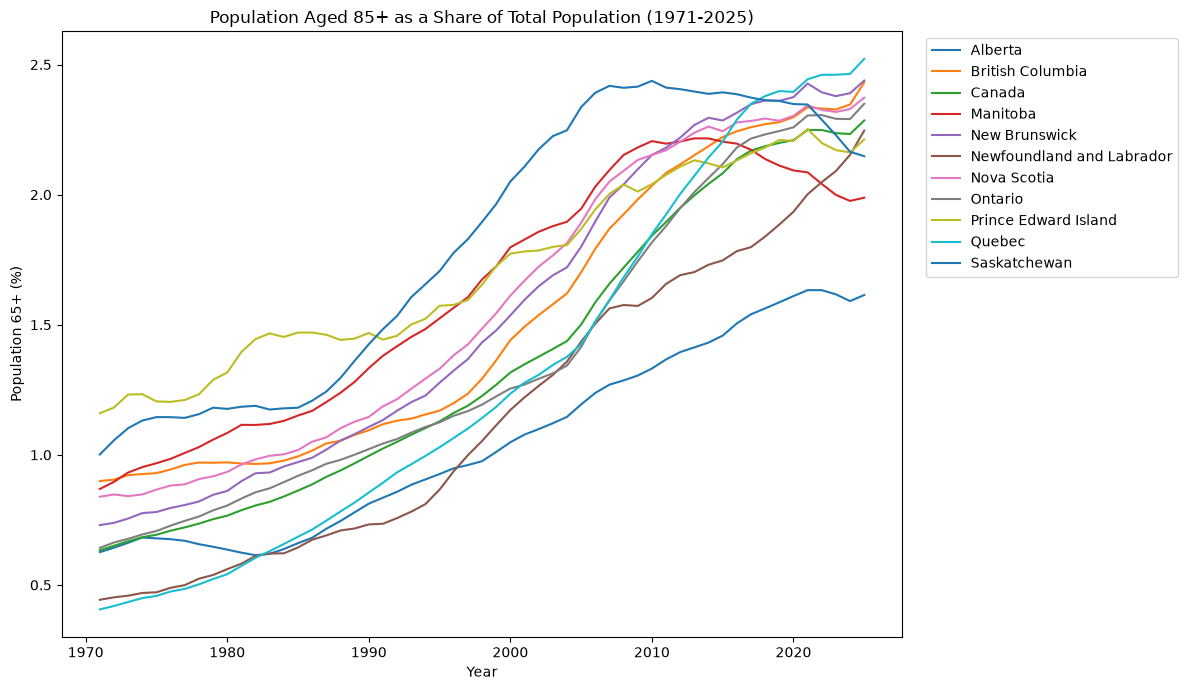

In [31]:
plt.figure(figsize=(12,7))
for province, group in df_population_demand.groupby("province_name"):
    plt.plot(
        group["data_year"],
        group["population_85_share_pct"],
        label=province
    )

plt.title("Population Aged 85+ as a Share of Total Population (1971-2025)")
plt.xlabel("Year")
plt.ylabel("Population 65+ (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### **1.5 -  Ageing Population Average Growth Across Provinces (1970-2024)**

#### **1.5.1 -  65+ Ageing Population Average Growth (1971-2024)**

In [32]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["growth_65_plus_pct"].mean().sort_values(ascending=False)

province_code  province_name            
AB             Alberta                      3.523458
BC             British Columbia             3.251933
ON             Ontario                      2.917073
QC             Quebec                       2.906892
CA             Canada                       2.868809
NL             Newfoundland and Labrador    2.729383
NB             New Brunswick                2.447813
NS             Nova Scotia                  2.288817
PE             Prince Edward Island         2.106832
MB             Manitoba                     1.868001
SK             Saskatchewan                 1.619172
Name: growth_65_plus_pct, dtype: float64

#### **1.5.2 - 80+ Ageing Population Average Growth (1971-2024)**

In [33]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["growth_80_plus_pct"].mean().sort_values(ascending=False)

province_code  province_name            
QC             Quebec                       3.732847
AB             Alberta                      3.558775
ON             Ontario                      3.409998
BC             British Columbia             3.369336
CA             Canada                       3.271171
NL             Newfoundland and Labrador    2.972885
NB             New Brunswick                2.626500
NS             Nova Scotia                  2.423681
PE             Prince Edward Island         2.035135
MB             Manitoba                     2.016864
SK             Saskatchewan                 1.615485
Name: growth_80_plus_pct, dtype: float64

#### **1.5.3 - 85+ Ageing Population Average Growth (1971-2024)**

In [34]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["growth_85_plus_pct"].mean().sort_values(ascending=False)

province_code  province_name            
QC             Quebec                       4.197329
AB             Alberta                      3.880415
ON             Ontario                      3.826419
BC             British Columbia             3.642279
CA             Canada                       3.630321
NL             Newfoundland and Labrador    3.128155
NB             New Brunswick                2.840086
NS             Nova Scotia                  2.548017
MB             Manitoba                     2.333069
PE             Prince Edward Island         2.128325
SK             Saskatchewan                 2.011016
Name: growth_85_plus_pct, dtype: float64

### **1.6 - Share of Ageing Population Across Province**

#### **1.6.1 - 65+ Share of Population**

In [35]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["population_65_share_pct"].mean().sort_values(ascending=False)

province_code  province_name            
PE             Prince Edward Island         14.586618
NS             Nova Scotia                  14.367337
NB             New Brunswick                14.095588
SK             Saskatchewan                 13.947016
BC             British Columbia             13.688489
MB             Manitoba                     13.341324
QC             Quebec                       12.972599
NL             Newfoundland and Labrador    12.773059
CA             Canada                       12.715964
ON             Ontario                      12.701371
AB             Alberta                       9.943182
Name: population_65_share_pct, dtype: float64

#### **1.6.2 - 80+ Share of Population**

In [36]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["population_80_share_pct"].mean().sort_values(ascending=False)

province_code  province_name            
SK             Saskatchewan                 3.705805
PE             Prince Edward Island         3.605707
MB             Manitoba                     3.385654
NS             Nova Scotia                  3.379624
NB             New Brunswick                3.314053
BC             British Columbia             3.242974
ON             Ontario                      2.980393
CA             Canada                       2.962691
QC             Quebec                       2.896239
NL             Newfoundland and Labrador    2.656953
AB             Alberta                      2.275562
Name: population_80_share_pct, dtype: float64

#### **1.6.3 - 85+ Share of Population**

In [37]:
df_population_demand.groupby(
    ["province_code", "province_name"]
)["population_85_share_pct"].mean().sort_values(ascending=False)

province_code  province_name            
SK             Saskatchewan                 1.806235
PE             Prince Edward Island         1.711046
MB             Manitoba                     1.621278
NS             Nova Scotia                  1.572262
NB             New Brunswick                1.539331
BC             British Columbia             1.512924
ON             Ontario                      1.373962
CA             Canada                       1.366380
QC             Quebec                       1.307931
NL             Newfoundland and Labrador    1.153584
AB             Alberta                      1.051798
Name: population_85_share_pct, dtype: float64

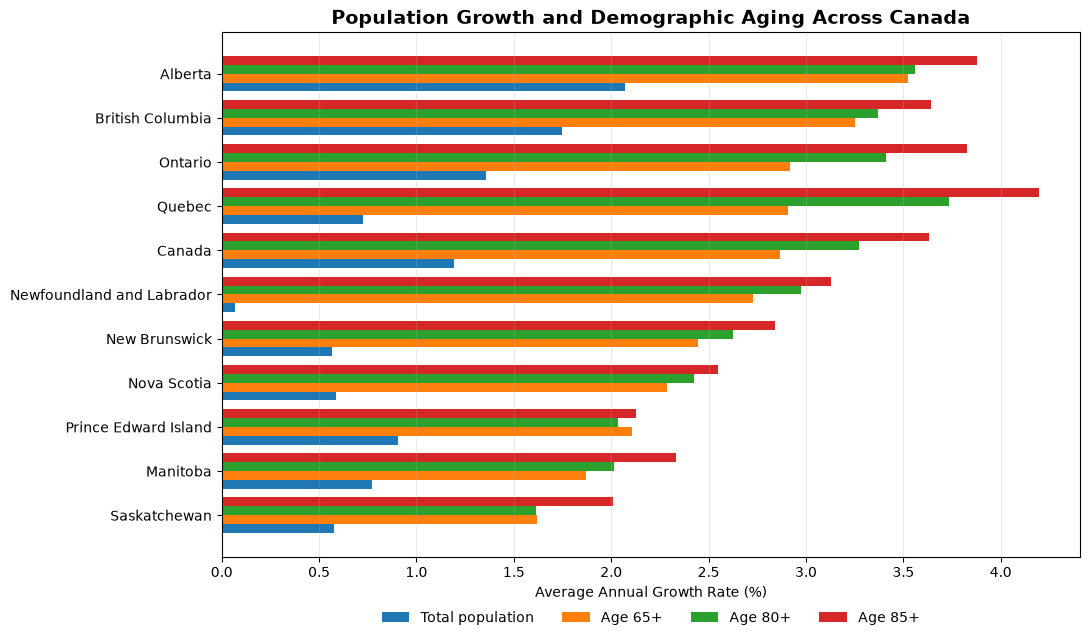

In [38]:
plot_df = (
    df_population_demand
    .groupby(["province_code", "province_name"])[
        [
            "population_growth_pct",
            "growth_65_plus_pct",
            "growth_80_plus_pct",
            "growth_85_plus_pct"
        ]
    ]
    .mean()
    .reset_index()
)

# Separate Canada from the provinces
canada = plot_df[plot_df["province_code"] == "CAN"]
provinces = plot_df[plot_df["province_code"] != "CAN"].copy()

# Sort provinces by 65+ growth
provinces = provinces.sort_values("growth_65_plus_pct")

# Add Canada as the benchmark
plot_df = pd.concat([provinces, canada], ignore_index=True)

# Plot
y = np.arange(len(plot_df))
height = 0.20

fig, ax = plt.subplots(figsize=(11, 6.5))

ax.barh(
    y - 1.5 * height,
    plot_df["population_growth_pct"],
    height,
    label="Total population"
)

ax.barh(
    y - 0.5 * height,
    plot_df["growth_65_plus_pct"],
    height,
    label="Age 65+"
)

ax.barh(
    y + 0.5 * height,
    plot_df["growth_80_plus_pct"],
    height,
    label="Age 80+"
)

ax.barh(
    y + 1.5 * height,
    plot_df["growth_85_plus_pct"],
    height,
    label="Age 85+"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["province_name"])

ax.set_xlabel("Average Annual Growth Rate (%)")

ax.set_title(
    "Population Growth and Demographic Aging Across Canada",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08)
)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [39]:
df_population_demand

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct,population_growth_pct,population_65_plus_growth_pct,population_80_plus_growth_pct,population_85_plus_growth_pct,growth_65_plus_pct,growth_80_plus_pct,growth_85_plus_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059,1.703351,2.602675,2.948345,4.438692,2.602675,2.948345,4.438692
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135,1.843881,2.748649,1.836719,4.865063,2.748649,1.836719,4.865063
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370,1.697881,2.409733,1.421126,4.805672,2.409733,1.421126,4.805672
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055,3.081463,3.161213,1.456670,2.580807,3.161213,1.456670,2.580807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,2.346385,0.027840,3.354136,0.856178,-0.047424,3.354136,0.856178,-0.047424
601,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,2.287928,0.949293,3.062977,0.179236,-1.565751,3.062977,0.179236,-1.565751
602,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,2.228618,2.668910,3.353580,1.327120,0.007416,3.353580,1.327120,0.007416
603,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,2.164812,3.107687,3.319465,1.430041,0.155717,3.319465,1.430041,0.155717


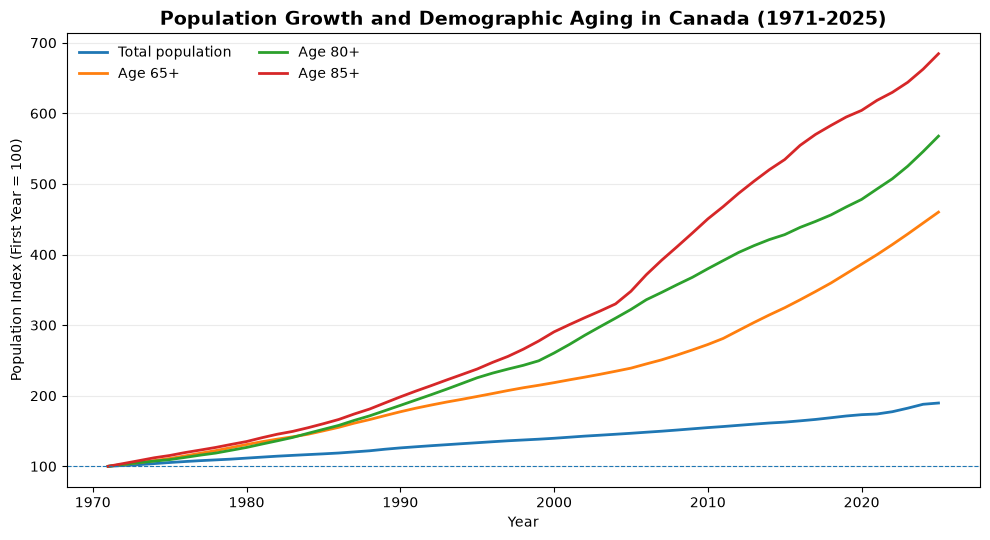

In [40]:
canada = (
    df_population_demand[
        df_population_demand["province_code"] == "CA"
    ]
    .copy()
    .sort_values("data_year")
)

# Population measures
population_cols = {
    "population": "Total population",
    "population_65_plus": "Age 65+",
    "population_80_plus": "Age 80+",
    "population_85_plus": "Age 85+"
}

# Index each series to 100 in the first common year
for col in population_cols:
    canada[f"{col}_index"] = (
        canada[col] / canada[col].iloc[0]
    ) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))

for col, label in population_cols.items():
    ax.plot(
        canada["data_year"],
        canada[f"{col}_index"],
        linewidth=2,
        label=label
    )

ax.axhline(
    100,
    linewidth=0.8,
    linestyle="--"
)

ax.set_title(
    "Population Growth and Demographic Aging in Canada (1971-2025)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Population Index (First Year = 100)")

ax.legend(
    frameon=False,
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

> ##### **Insights:** 
> - ##### The data suggests that Canadian demographic ageing pressue varies across provinces. Some Atlantic provinces and Saskatchewan have relatively high concentrations of older population, while some territories experienced faster growth in older age group from a smaller population bases. At the national level, 80 plus and 85 plus populations are growing faster compared to 65 plus population. As a result, healthcare demand will likely evolve through population growth and changes in the age composition of the population.

<table width="100%">
<tr>
<td width="50%" align="left"><a href="./00_EDA.ipynb">← Previous: EDA</a></td>
<td width="50%" align="right"><a href="./02_RQ2_capacity_workforce.ipynb">Next: RQ2 — Capacity Workforce →</a></td>
</tr>
</table>